# RoPE (Rotary Position Embeddings) - Exercise Notebook

Bu notebook, RoPE'un nasıl çalıştığını ve Attention Layer'a nasıl uygulandığını adım adım öğrenmenizi sağlar.

## İçerik:
1. RoPE Temelleri ve Frekans Hesaplama
2. RoPE Uygulama (Dönüşüm)
3. Attention Layer'a RoPE Entegrasyonu
4. Alıştırmalar (Exercises)
5. Visualizasyonlar

---

## Bölüm 1: RoPE Temelleri ve Frekans Hesaplama

### Exercise 1.1: Frekansları Anlama

RoPE'da her boyut (dimension) için farklı bir frekans kullanılır. Bu, farklı mesafelerdeki ilişkileri yakalamak için gereklidir.

Formül:
$$\text{inv\_freq}_i = \frac{1}{\theta^{2i / d}}$$

Nerede:
- $\theta$ = theta_base (genellikle 10000)
- $d$ = head_dim
- $i$ = boyut indeksi

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# === EXERCISE 1.1: Frekansları hesapla ===
head_dim = 8
theta_base = 10000

# Görev: İlk 4 çift indeks için inv_freq hesapla
# İpucu: torch.arange(0, head_dim, 2) kullan


In [11]:
torch.arange(0, head_dim, 2)


tensor([0, 2, 4, 6])

In [12]:

indices = torch.arange(0, head_dim, 2)[: head_dim // 2]


In [13]:
%dirs

[]

### Exercise 1.2: Açıları Hesapla

Her pozisyon için açıları hesaplarız:
$$\text{angles}_{p,i} = p \times \text{inv\_freq}_i$$

Nerede $p$ = pozisyon, $i$ = boyut indeksi

In [14]:
# === EXERCISE 1.2: Açıları hesapla ===
context_length = 5  # Sadece 5 token

# Pozisyonları oluştur
positions = torch.arange(context_length)

# Görev: angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0) hesapla
angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)

print("Pozisyonlar:", positions.tolist())
print("İnverse frekanslar:", inv_freq.tolist())
print("Açılar (her satır bir pozisyon):")
print(angles)
print()

# Soru: Pozisyon 2'deki açı, pozisyon 1'dekinin kaç katı?
# Cevap: 2 katı (doğrusal ilişki)

Pozisyonlar: [0, 1, 2, 3, 4]
İnverse frekanslar: [1.0, 0.10000000149011612, 0.009999999776482582, 0.0010000000474974513]
Açılar (her satır bir pozisyon):
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+00, 1.0000e-01, 1.0000e-02, 1.0000e-03],
        [2.0000e+00, 2.0000e-01, 2.0000e-02, 2.0000e-03],
        [3.0000e+00, 3.0000e-01, 3.0000e-02, 3.0000e-03],
        [4.0000e+00, 4.0000e-01, 4.0000e-02, 4.0000e-03]])



### Exercise 1.3: Boyutu İki Katına Çıkar ve cos/sin Hesapla

RoPE her boyut çifti için çalışır, bu yüzden açıları iki kez tekrarlarız.

In [15]:
# === EXERCISE 1.3: cos ve sin hesapla ===

# Görev 1: angles'ı iki katına çıkar (torch.cat)
angles_expanded = torch.cat([angles, angles], dim=1)

# Görev 2: cos ve sin hesapla
cos_values = torch.cos(angles_expanded)
sin_values = torch.sin(angles_expanded)

print("Açılar (genişletilmiş):")
print(angles_expanded)
print()

print("Cos değerleri:")
print(cos_values)
print()

print("Sin değerleri:")
print(sin_values)
print()

# Soru: Pozisyon 0'da cos neden 1?
# Cevap: cos(0) = 1

Açılar (genişletilmiş):
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [1.0000e+00, 1.0000e-01, 1.0000e-02, 1.0000e-03, 1.0000e+00, 1.0000e-01,
         1.0000e-02, 1.0000e-03],
        [2.0000e+00, 2.0000e-01, 2.0000e-02, 2.0000e-03, 2.0000e+00, 2.0000e-01,
         2.0000e-02, 2.0000e-03],
        [3.0000e+00, 3.0000e-01, 3.0000e-02, 3.0000e-03, 3.0000e+00, 3.0000e-01,
         3.0000e-02, 3.0000e-03],
        [4.0000e+00, 4.0000e-01, 4.0000e-02, 4.0000e-03, 4.0000e+00, 4.0000e-01,
         4.0000e-02, 4.0000e-03]])

Cos değerleri:
tensor([[ 1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000],
        [ 0.5403,  0.9950,  0.9999,  1.0000,  0.5403,  0.9950,  0.9999,  1.0000],
        [-0.4161,  0.9801,  0.9998,  1.0000, -0.4161,  0.9801,  0.9998,  1.0000],
        [-0.9900,  0.9553,  0.9996,  1.0000, -0.9900,  0.9553,  0.9996,  1.0000],
        [-0.6536,  0.9211,  0.9992,  1.0000, -0.6536,  0

### Visualization 1: Frekansları Görselleştir

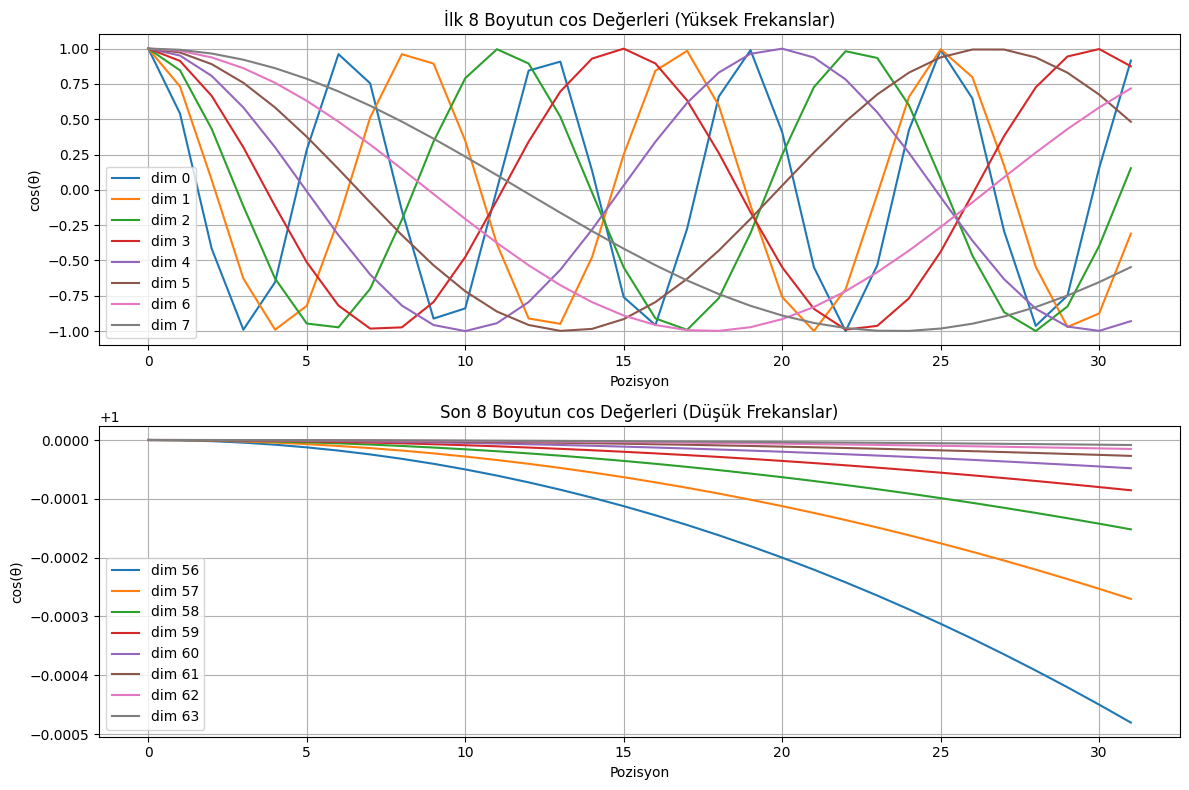

In [16]:
# === VISUALIZATION 1: Frekansları görselleştir ===
head_dim = 64
theta_base = 10000
context_length = 32

indices = torch.arange(0, head_dim, 2)[: head_dim // 2]
inv_freq = 1.0 / (theta_base ** (indices.float() / head_dim))

positions = torch.arange(context_length)
angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)
angles_expanded = torch.cat([angles, angles], dim=1)

cos_vals = torch.cos(angles_expanded)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# İlk birkaç boyutun cos değerleri
ax1 = axes[0]
for i in range(8):
    ax1.plot(positions.numpy(), cos_vals[:, i].numpy(), label=f'dim {i}')
ax1.set_xlabel('Pozisyon')
ax1.set_ylabel('cos(θ)')
ax1.set_title('İlk 8 Boyutun cos Değerleri (Yüksek Frekanslar)')
ax1.legend()
ax1.grid(True)

# Son birkaç boyutun cos değerleri
ax2 = axes[1]
for i in range(head_dim - 8, head_dim):
    ax2.plot(positions.numpy(), cos_vals[:, i].numpy(), label=f'dim {i}')
ax2.set_xlabel('Pozisyon')
ax2.set_ylabel('cos(θ)')
ax2.set_title('Son 8 Boyutun cos Değerleri (Düşük Frekanslar)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Yüksek frekanslar: Hızlı salınım, kısa mesafeler için
# Düşük frekanslar: Yavaş salınım, uzun mesafeler için

---

## Bölüm 2: RoPE Dönüşümünü Uygulama

### RoPE Dönüşüm Formülü

$$x_{rotated} = x \cdot \cos(\theta) + \text{rotated}(x) \cdot \sin(\theta)$$

Nerede:
- $x$ = orijinal vektör
- $\text{rotated}(x)$ = $[-x_{d/2}, ..., -x_{d-1}, x_0, ..., x_{d/2-1}]$

In [17]:
# === ROPE Dönüşüm Fonksiyonu ===

def compute_rope(x, cos, sin):
    """
    RoPE dönüşümünü uygula
    
    Args:
        x: (batch, num_heads, seq_len, head_dim)
        cos: (seq_len, head_dim)
        sin: (seq_len, head_dim)
    
    Returns:
        x_rotated: (batch, num_heads, seq_len, head_dim)
    """
    batch_size, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 == 0, "Head dimension must be even"

    # Adım 1: x'i ikiye böl
    x1 = x[..., : head_dim // 2]  # İlk yarı
    x2 = x[..., head_dim // 2 :]  # İkinci yarı

    # Adım 2: Rotated versiyon oluştur
    # [-x2, x1] -> x2'yi negatif alıp başa koy
    rotated = torch.cat((-x2, x1), dim=-1)

    # Adım 3: cos ve sin'i uygun şekle getir
    cos = cos[:seq_len, :].unsqueeze(0).unsqueeze(0)  # (1, 1, seq_len, head_dim)
    sin = sin[:seq_len, :].unsqueeze(0).unsqueeze(0)

    # Adım 4: Dönüşüm formülünü uygula
    x_rotated = (x * cos) + (rotated * sin)

    return x_rotated.to(dtype=x.dtype)


# Test edelim
batch_size, num_heads, seq_len, head_dim = 2, 4, 5, 16
x = torch.randn(batch_size, num_heads, seq_len, head_dim)

# Önceki adımdan cos ve sin
cos_test = torch.cos(angles_expanded)
sin_test = torch.sin(angles_expanded)

x_rotated = compute_rope(x, cos_test, sin_test)

print("Orijinal x shape:", x.shape)
print("RoPE uygulanmış x shape:", x_rotated.shape)
print("Değişiklik var mı?", not torch.allclose(x, x_rotated))

RuntimeError: The size of tensor a (16) must match the size of tensor b (64) at non-singleton dimension 3

### Exercise 2.1: Pozisyon 0'da Değişiklik Yok

RoPE'un önemli bir özelliği: Pozisyon 0'daki token DEĞİŞMEZ (cos(0)=1, sin(0)=0).

In [ ]:
# === EXERCISE 2.1: Pozisyon 0'ın değişmediğini doğrula ===

# Sadece pozisyon 0'ı al
x_pos0 = x[:, :, 0:1, :]  # (batch, heads, 1, head_dim)
x_rotated_pos0 = x_rotated[:, :, 0:1, :]

print("Pozisyon 0 - Orijinal:")
print(x_pos0[0, 0, 0, :8])  # İlk batch, ilk head, ilk 8 boyut
print()

print("Pozisyon 0 - RoPE uygulanmış:")
print(x_rotated_pos0[0, 0, 0, :8])
print()

print("Eşit mi?", torch.allclose(x_pos0, x_rotated_pos0))

# Soru: Neden eşit olması gerekiyor?
# Cevap: cos(0)=1, sin(0)=0 olduğu için x*1 + rotated*0 = x

### Exercise 2.2: Relative Position İlişkisi

RoPE'un gücü: Pozisyonlar arasındaki mesafeyi otomatik olarak yakalar.

In [ ]:
# === EXERCISE 2.2: Relative position ilişkisini göster ===

# Basit bir vektör oluştur
simple_x = torch.zeros(1, 1, 3, 8)  # 3 pozisyon, 8 boyut
simple_x[0, 0, 0, :] = torch.tensor([1., 2., 3., 4., 5., 6., 7., 8.])
simple_x[0, 0, 1, :] = torch.tensor([1., 2., 3., 4., 5., 6., 7., 8.])
simple_x[0, 0, 2, :] = torch.tensor([1., 2., 3., 4., 5., 6., 7., 8.])

# Basit cos/sin (sadece gösterim)
simple_cos = torch.ones(3, 8)
simple_sin = torch.zeros(3, 8)
simple_cos[1, :4] = 0.5  # Pozisyon 1
simple_sin[1, :4] = 0.866  # ~sin(60°)
simple_cos[2, :4] = -0.5  # Pozisyon 2
simple_sin[2, :4] = 0.866

simple_rotated = compute_rope(simple_x, simple_cos, simple_sin)

print("Pozisyon 0 (referans):", simple_rotated[0, 0, 0, :4].tolist())
print("Pozisyon 1:", simple_rotated[0, 0, 1, :4].tolist())
print("Pozisyon 2:", simple_rotated[0, 0, 2, :4].tolist())
print()

# Pozisyon 1 ve 2 arasındaki fark
diff_1_2 = simple_rotated[0, 0, 2, :4] - simple_rotated[0, 0, 1, :4]
print("Pozisyon 2 - Pozisyon 1:", diff_1_2.tolist())

# Soru: Bu fark pozisyon 1'in kendisinden farklı mı?
# RoPE sayesinde "arada kaç kelime var" bilgisi encoded!

---

## Bölüm 3: Attention Layer'a RoPE Entegrasyonu

### RoPE Attention'da Nereye Uygulanır?

```
Input → Q, K, V hesapla → [RoPE Q ve K'ya uygula] → Attention Scores → Output
```

RoPE sadece Query ve Key'e uygulanır, Value'ya DEĞİL!

In [ ]:
# === RoPE ile Multi-Head Attention ===

import torch.nn as nn
import math

class RoPEMultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, num_heads, dropout=0.0):
        super().__init__()
        assert d_out % num_heads == 0
        
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.context_length = context_length
        
        # Q, K, V projeleri
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)
        self.out_proj = nn.Linear(d_out, d_out, bias=False)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Causal mask (alt üçgen)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1).to(torch.bool)
        )
        
        # === ROPE PARAMETRELERİNİ HESAPLA ===
        self.register_rope_buffers()
    
    def register_rope_buffers(self):
        """RoPE için cos ve sin değerlerini precompute et"""
        # Frekansları hesapla
        inv_freq = 1.0 / (10000 ** (torch.arange(0, self.head_dim, 2).float() / self.head_dim))
        
        # Pozisyonlar ve açılar
        positions = torch.arange(self.context_length)
        angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)
        angles = torch.cat([angles, angles], dim=1)
        
        # cos ve sin buffer olarak kaydet
        self.register_buffer("cos", torch.cos(angles), persistent=False)
        self.register_buffer("sin", torch.sin(angles), persistent=False)
    
    def compute_rope(self, x):
        """RoPE dönüşümü"""
        batch_size, num_heads, seq_len, head_dim = x.shape
        
        x1 = x[..., : head_dim // 2]
        x2 = x[..., head_dim // 2:]
        
        rotated = torch.cat((-x2, x1), dim=-1)
        
        cos = self.cos[:seq_len, :].unsqueeze(0).unsqueeze(0)
        sin = self.sin[:seq_len, :].unsqueeze(0).unsqueeze(0)
        
        return (x * cos + rotated * sin).to(dtype=x.dtype)
    
    def forward(self, x):
        b, num_tokens, d_in = x.shape
        
        # Q, K, V hesapla
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)
        
        # Head'lere böl
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        
        # === ROPE'U Q VE K'YA UYGULA ===
        queries = self.compute_rope(queries)
        keys = self.compute_rope(keys)
        
        # Attention scores
        attn_scores = queries @ keys.transpose(2, 3)
        
        # Mask uygula
        mask_bool = self.mask[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        # Softmax
        attn_weights = torch.softmax(attn_scores / math.sqrt(self.head_dim), dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Context vector
        context_vec = attn_weights @ values
        
        # Combine heads
        context_vec = context_vec.transpose(1, 2).reshape(b, num_tokens, d_out)
        
        return self.out_proj(context_vec)


# Test
batch_size = 2
seq_len = 10
d_in = 64
d_out = 64
num_heads = 4
context_length = 128

x = torch.randn(batch_size, seq_len, d_in)

mha = RoPEMultiHeadAttention(d_in, d_out, context_length, num_heads)
output = mha(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

### Exercise 3.1: RoPE vs Absolute Position Karşılaştırması

In [ ]:
# === EXERCISE 3.1: RoPE vs Absolute Position Embedding ===

# 1. Absolute Position Embedding (GPT tarzı)
class AbsolutePositionEmbedding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        self.pos_emb = nn.Embedding(max_len, d_model)
    
    def forward(self, x):
        b, seq_len, d_model = x.shape
        positions = torch.arange(seq_len, device=x.device)
        return x + self.pos_emb(positions)


# 2. RoPE (Bizim implementasyonumuz)
class RoPEPositionEmbedding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len
        self.register_rope_buffers()
    
    def register_rope_buffers(self):
        head_dim = self.d_model  # Basitlik için tüm model boyutu
        inv_freq = 1.0 / (10000 ** (torch.arange(0, head_dim, 2).float() / head_dim))
        positions = torch.arange(self.max_len)
        angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)
        angles = torch.cat([angles, angles], dim=1)
        self.register_buffer("cos", torch.cos(angles))
        self.register_buffer("sin", torch.sin(angles))
    
    def forward(self, x):
        # RoPE x'in kendisini DEĞİŞTİRMEZ, sadece attention'da kullanılır
        # Burada sadece embedding'i döndürüyoruz
        return x  # RoPE input'a eklenmez, attention'da uygulanır


# Karşılaştırma
d_model = 16
seq_len = 8
x = torch.randn(1, seq_len, d_model)

abs_pos = AbsolutePositionEmbedding(d_model)
rope_pos = RoPEPositionEmbedding(d_model)

x_abs = abs_pos(x)
x_rope = rope_pos(x)

print("=== FARKLILIKLAR ===")
print()

print("1. Parametre sayısı:")
print(f"   Absolute: {sum(p.numel() for p in abs_pos.parameters()):,} parametre")
print(f"   RoPE: {sum(p.numel() for p in rope_pos.parameters()):,} parametre (sadece buffer)")
print()

print("2. Uzun bağlam desteği:")
print(f"   Absolute: max_len=512 ile sınırlı")
print(f"   RoPE: Sınırsız (formül ile hesaplanır)")
print()

print("3. Pozisyon bilgisi:")
print(f"   Absolute: Her pozisyon için ayrı embedding")
print(f"   RoPE: Sadece Q ve K'ya uygulanır, relative position bilgisi")
print()

print("4. Input değişikliği:")
print(f"   Absolute: x + pos_embedding (inplace değişiklik)")
print(f"   RoPE: x değişmez, attention scores hesaplanırken uygulanır")

### Visualization 2: Attention Pattern Karşılaştırması

In [ ]:
# === VISUALIZATION 2: Attention pattern karşılaştırması ===

# Basit bir attention modeli oluştur
def simple_attention_with_rope(q, k, v, cos, sin):
    """Basit attention + RoPE"""
    seq_len = q.shape[2]
    head_dim = q.shape[3]
    
    # RoPE uygula
    q1 = q[..., : head_dim // 2]
    q2 = q[..., head_dim // 2:]
    rotated_q = torch.cat((-q2, q1), dim=-1)
    q = (q * cos[:seq_len]) + (rotated_q * sin[:seq_len])
    
    k1 = k[..., : head_dim // 2]
    k2 = k[..., head_dim // 2:]
    rotated_k = torch.cat((-k2, k1), dim=-1)
    k = (k * cos[:seq_len]) + (rotated_k * sin[:seq_len])
    
    # Attention
    scores = q @ k.transpose(2, 3) / (head_dim ** 0.5)
    return torch.softmax(scores, dim=-1)


def simple_attention_no_rope(q, k, v):
    """Basit attention (RoPE yok)"""
    scores = q @ k.transpose(2, 3) / (q.shape[-1] ** 0.5)
    return torch.softmax(scores, dim=-1)


# Test
batch, heads, seq_len, head_dim = 1, 1, 10, 16
torch.manual_seed(42)

q = torch.randn(batch, heads, seq_len, head_dim)
k = torch.randn(batch, heads, seq_len, head_dim)
v = torch.randn(batch, heads, seq_len, head_dim)

# RoPE parametreleri
inv_freq = 1.0 / (10000 ** (torch.arange(0, head_dim, 2).float() / head_dim))
positions = torch.arange(seq_len)
angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)
angles = torch.cat([angles, angles], dim=1)
cos_vals = torch.cos(angles)
sin_vals = torch.sin(angles)

# Attention hesapla
attn_no_rope = simple_attention_no_rope(q, k, v)
attn_with_rope = simple_attention_with_rope(q, k, v, cos_vals, sin_vals)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(attn_no_rope[0, 0].detach().numpy(), cmap='viridis')
axes[0].set_title('Attention (RoPE yok)')
axes[0].set_xlabel('Key Position')
axes[0].set_ylabel('Query Position')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(attn_with_rope[0, 0].detach().numpy(), cmap='viridis')
axes[1].set_title('Attention (RoPE ile)')
axes[1].set_xlabel('Key Position')
axes[1].set_ylabel('Query Position')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

# Soru: Farklılıkları görüyor musunuz?
# RoPE ile attention daha "düzgün" ve pozisyonlar arası ilişki daha belirgin

---

## Bölüm 4: Alıştırmalar (Exercises)

### Öğrendiklerimizi Pekiştirelim!

Aşağıdaki alıştırmaları kendi başınıza çözmeye çalışın.

### Quiz 1: RoPE Temel Sorular

**Soru 1**: RoPE'da neden sadece Query ve Key'e uygulanır, Value'ya uygulanmaz?

**Soru 2**: Pozisyon 0'daki token neden değişmez?

**Soru 3**: RoPE'un relative position bilgisi encode ettiğini nasıl gösterirsiniz?

In [ ]:
# === CEVAPLAR ===

print("=" * 50)
print("CEVAPLAR")
print("=" * 50)
print()

print("Soru 1: Neden sadece Q ve K'ya uygulanır?")
print("-" * 40)
print("Çünkü attention score'lar Q @ K^T ile hesaplanır.")
print("RoPE uygulandığında, Q ve K'nın pozisyonları arasındaki")
print("fark otomatik olarak score'lara yansır.")
print("Value zaten attention sonrası karıştırılmış bilgi içeriyor,")
print("pozisyon bilgisine ihtiyaç yok.")
print()

print("Soru 2: Pozisyon 0 neden değişmez?")
print("-" * 40)
print("cos(0) = 1, sin(0) = 0")
print("x_rotated = x * 1 + rotated * 0 = x")
print("Bu sebeple pozisyon 0 referans noktası olarak kalır.")
print()

print("Soru 3: Relative position kanıtı?")
print("-" * 40)
print("RoPE formülünde: Q(p) @ K(q)^T")
print("Bu çarpım açıların farkını içerir.")
print("Sonuç: (p - q) yani pozisyonlar arası mesafe!")
print("Model 'benimle 5 kelime sonra ne var' diye sorabilir.")

### Quiz 2: Kodlama Alıştırması

In [ ]:
# === ALIŞTIRMA: Llama tarzı FeedForward oluştur ===

# Llama'da SwiGLU kullanılır:
# SwiGLU(x) = SiLU(Linear1(x)) * Linear2(x)
# Output = Linear3(gated_output)

# GÖREV: Aşağıdaki sınıfı tamamlayın

class SwiGLUFeedForward(nn.Module):
    def __init__(self, d_in, hidden_dim, d_out):
        super().__init__()
        # TODO: 3 linear layer tanımlayın
        # fc1: d_in -> hidden_dim (gate için)
        # fc2: d_in -> hidden_dim (value için)
        # fc3: hidden_dim -> d_out (output)
        # NOT: bias=False (Llama'da bias yok)
        self.fc1 = nn.Linear(d_in, hidden_dim, bias=False)
        self.fc2 = nn.Linear(d_in, hidden_dim, bias=False)
        self.fc3 = nn.Linear(hidden_dim, d_out, bias=False)
    
    def forward(self, x):
        # TODO: SwiGLU formülünü uygulayın
        # gate = SiLU(fc1(x))
        # value = fc2(x)
        # output = fc3(gate * value)
        gate = torch.nn.functional.silu(self.fc1(x))
        value = self.fc2(x)
        return self.fc3(gate * value)


# Test
x = torch.randn(2, 10, 64)
ff = SwiGLUFeedForward(64, 256, 64)
out = ff(x)
print("Input:", x.shape)
print("Output:", out.shape)

---

## Özet

Bu notebook'ta şunları öğrendik:

### RoPE'un Temelleri:
1. **Frekanslar**: Her boyut için farklı frekans (yüksek -> düşük)
2. **Açılar**: Pozisyon × Frekans
3. **cos/sin**: Açıların trigonometrik değerleri

### RoPE Dönüşümü:
1. Vektörü ikiye böl
2. İkinci yarıyı negatif alarak başa koy
3. Formülü uygula: x*cos + rotated*sin

### Attention'a Entegrasyon:
1. Q ve K hesapla
2. RoPE uygula (sadece Q ve K)
3. Attention scores hesapla
4. Value ile çarp

### RoPE'un Avantajları:
- Uzun bağlam desteği (100K+ token)
- Relative position bilgisi
- Parametre tasarrufu (absolute embedding yok)
- Extrapolation yeteneği

---

**Kaynaklar:**
- [RoFormer Paper](https://arxiv.org/abs/2104.09864)
- [Llama 2 Paper](https://arxiv.org/abs/2307.09288)
- [GLU Variants Paper](https://arxiv.org/abs/2002.05202)